# Exercise 4: Blast Off!

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Reading Text File

In [23]:
def parse_apollo(filename):

    data = {}
    headings = None

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if line.startswith("$") or line == "":
                continue # ignore

            # Creating lists to store each columns data
            if line.startswith("TIME"):
                headings = [i.strip() for i in line.split(",")]
                for h in headings:
                    data[h] = []
                continue

            # Appedning each value to correct column
            if headings and "," in line:
                parts = [i.strip() for i in line.split(",")]
                if len(parts) == len(headings):
                    try:
                        # converting to floats
                        nums = list(map(float, parts))
                        for i in range(len(headings)):
                            column = headings[i]
                            value = nums[i]
                            data[column].append(value)
                    except ValueError:
                        #skipping rows without numeric data
                        pass

    # converting data
    for h in data:
        data[h] = np.array(data[h])

    return data

In [24]:
filename = 'as-505-ascent-phase-data.txt'
datas = parse_apollo(filename)
datas

{'TIME': array([0.0000e+00, 2.5000e-01, 5.3000e-01, 1.0000e+00, 2.0000e+00,
        3.0000e+00, 4.0000e+00, 5.0000e+00, 6.0000e+00, 7.0000e+00,
        8.0000e+00, 9.0000e+00, 1.0000e+01, 1.5000e+01, 2.0000e+01,
        2.5000e+01, 3.0000e+01, 3.5000e+01, 4.0000e+01, 4.5000e+01,
        5.0000e+01, 5.5000e+01, 6.0000e+01, 6.5000e+01, 7.0000e+01,
        7.5000e+01, 8.0000e+01, 8.5000e+01, 9.0000e+01, 9.5000e+01,
        1.0000e+02, 1.0500e+02, 1.1000e+02, 1.1500e+02, 1.2000e+02,
        1.2500e+02, 1.3000e+02, 1.3500e+02, 1.4000e+02, 1.4500e+02,
        1.5000e+02, 1.5500e+02, 1.6000e+02, 1.6400e+02, 1.7000e+02,
        1.8000e+02, 1.9000e+02, 2.0000e+02, 2.1000e+02, 2.2000e+02,
        2.3000e+02, 2.4000e+02, 2.5000e+02, 2.6000e+02, 2.7000e+02,
        2.8000e+02, 2.9000e+02, 3.0000e+02, 3.1000e+02, 3.2000e+02,
        3.3000e+02, 3.4000e+02, 3.5000e+02, 3.6000e+02, 3.7000e+02,
        3.8000e+02, 3.9000e+02, 4.0000e+02, 4.1000e+02, 4.2000e+02,
        4.3000e+02, 4.4000e+02, 4.5000e+

### Plotting Parameters

In [29]:
def plot_parameters(data):
    time = data['TIME']
    for key in data:
        if key == 'TIME':
            continue
        plt.figure(figsize=(10,5))
        plt.plot(time, data[key])
        plt.xlabel("Time (s)")
        plt.ylabel(key)
        plt.title(f"{key} vs Time")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Will find a way to inlcude units later

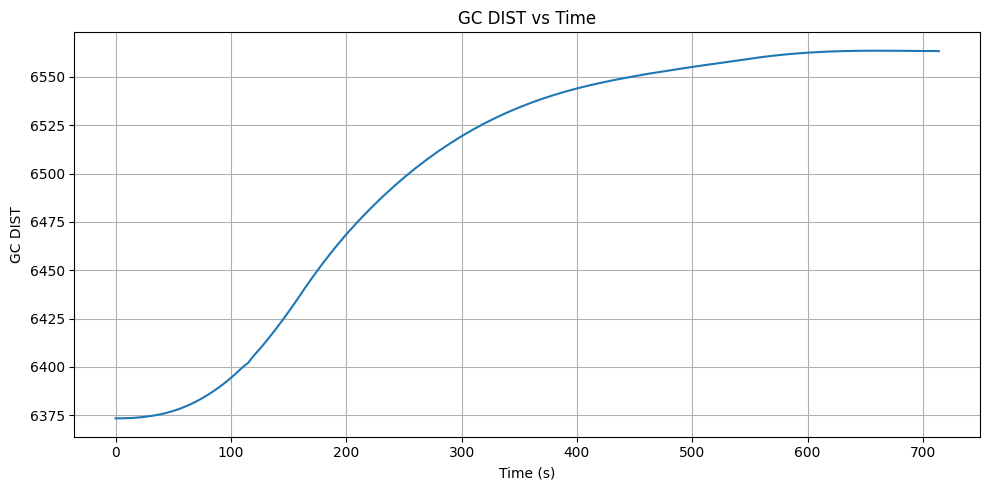

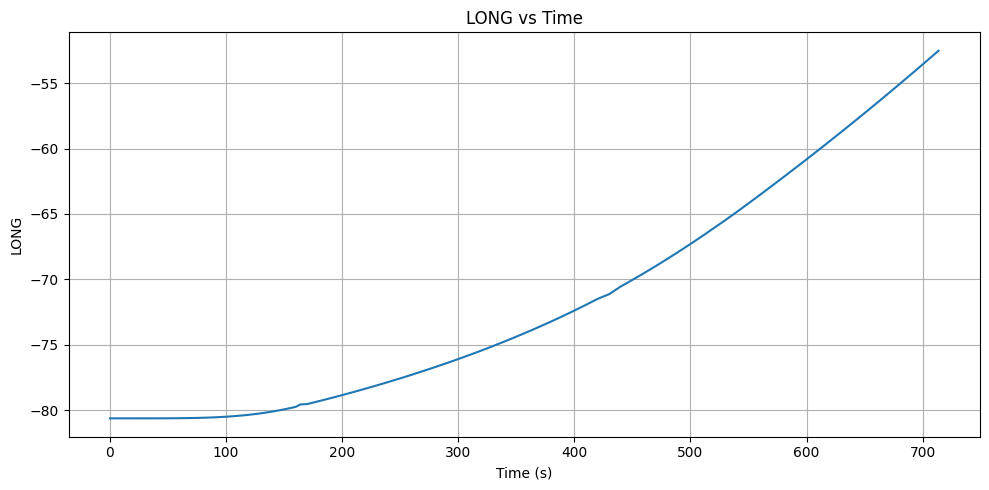

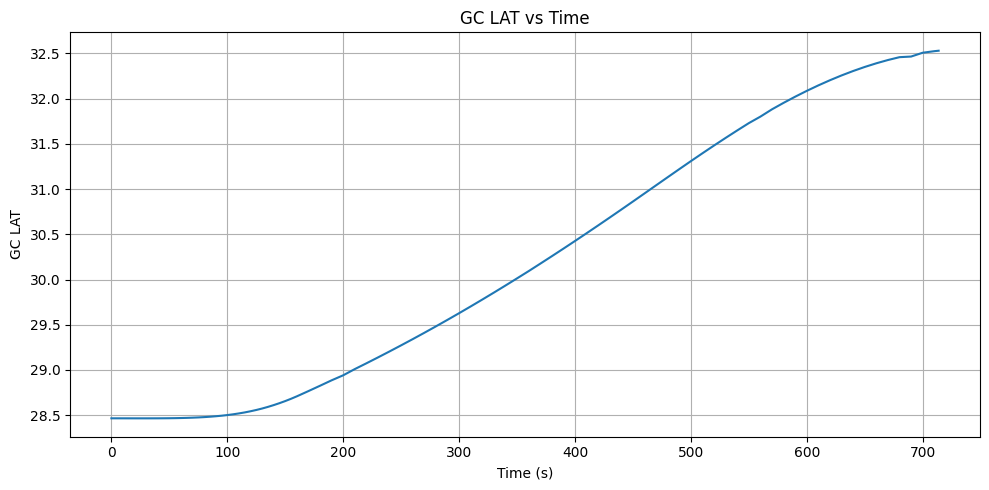

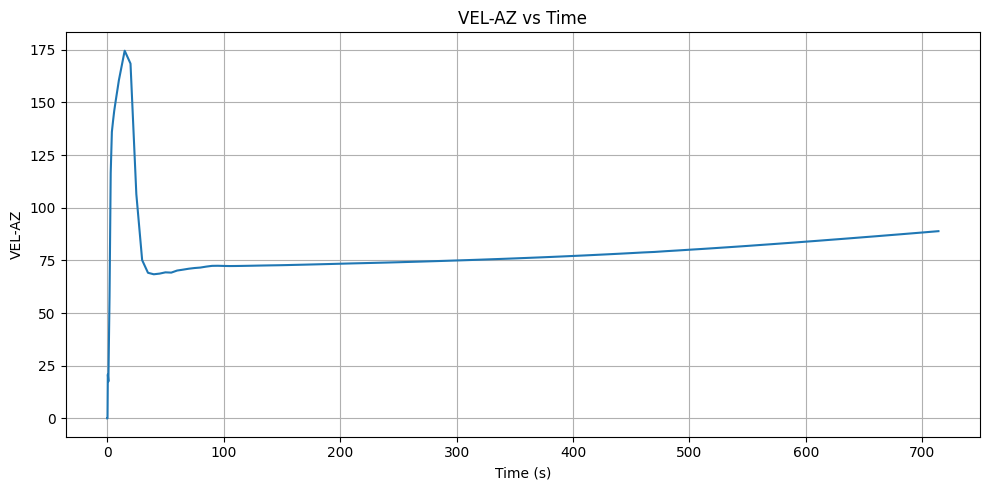

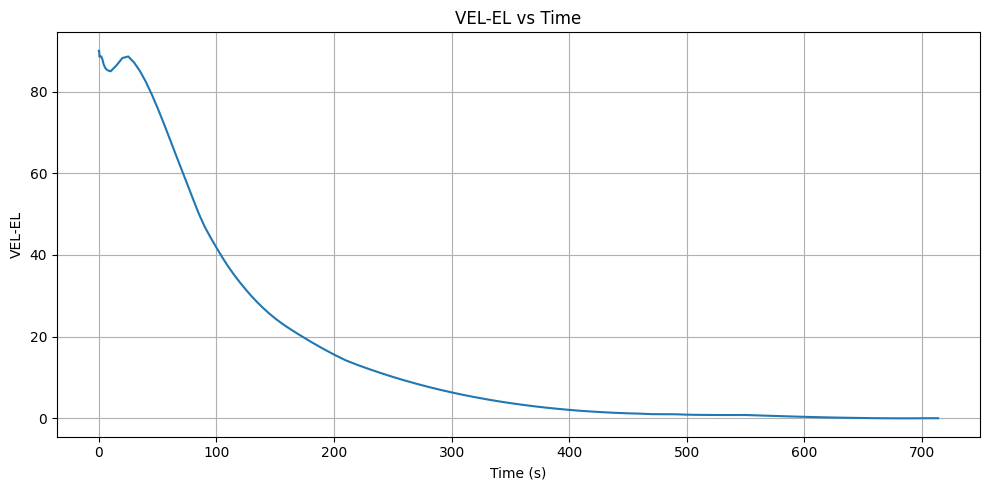

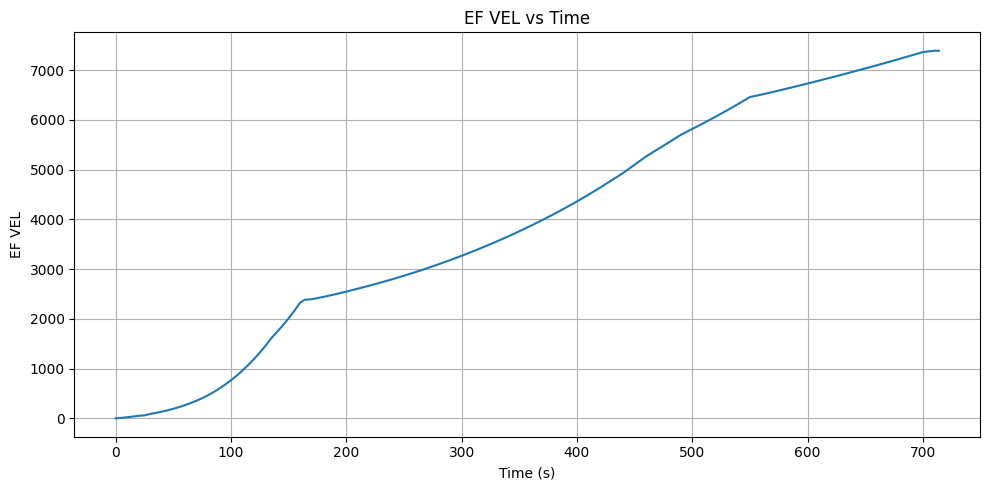

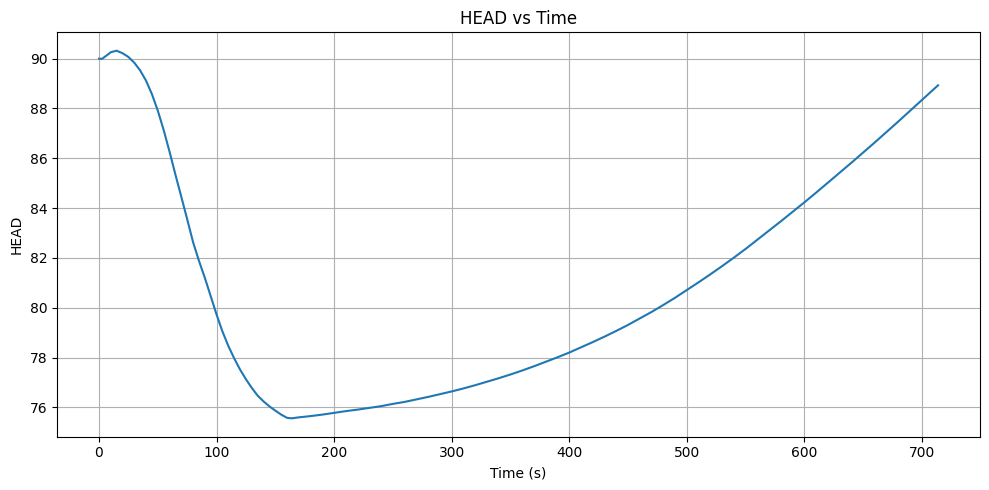

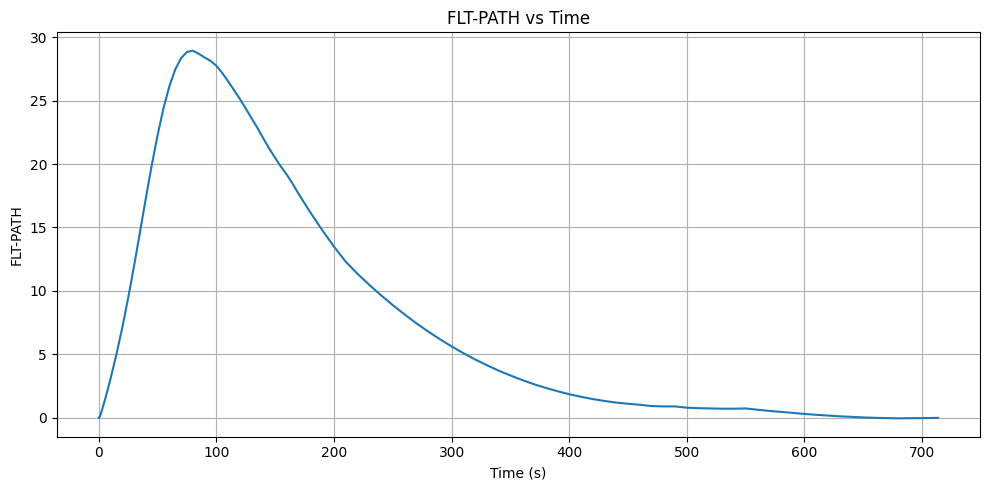

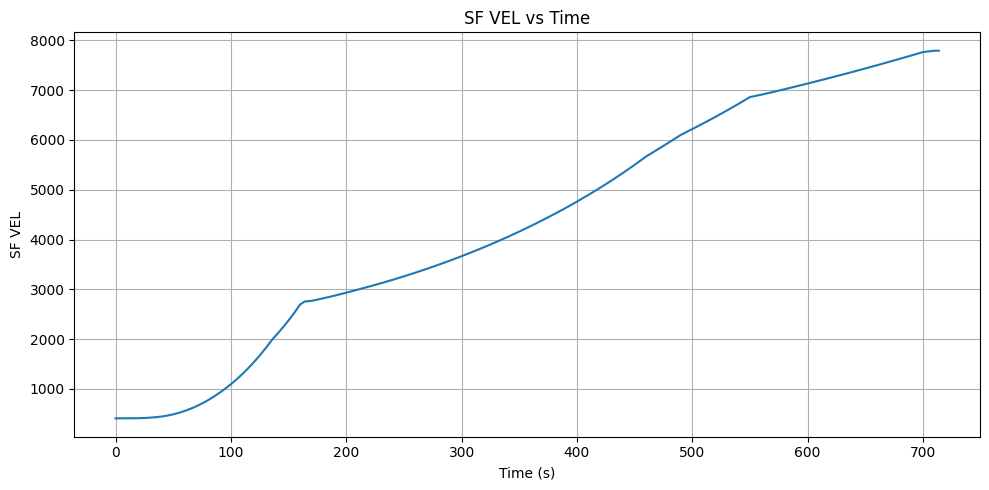

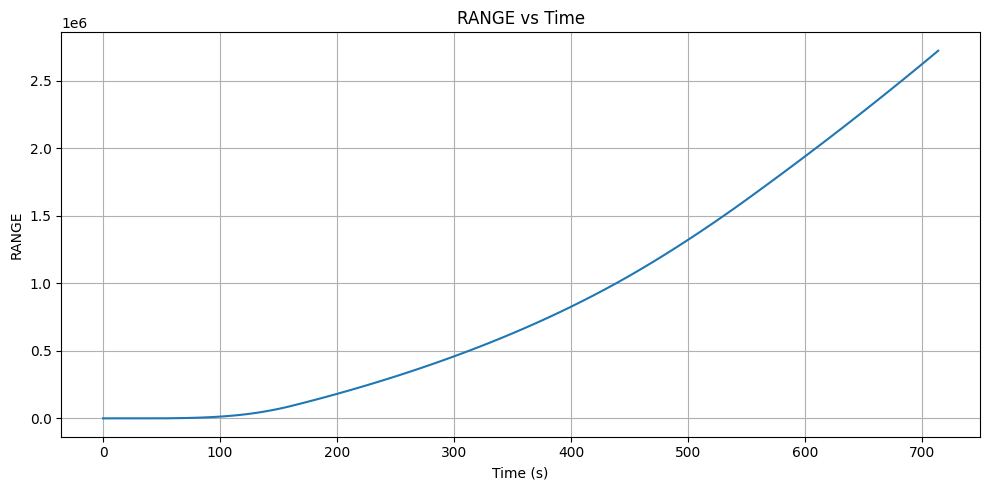

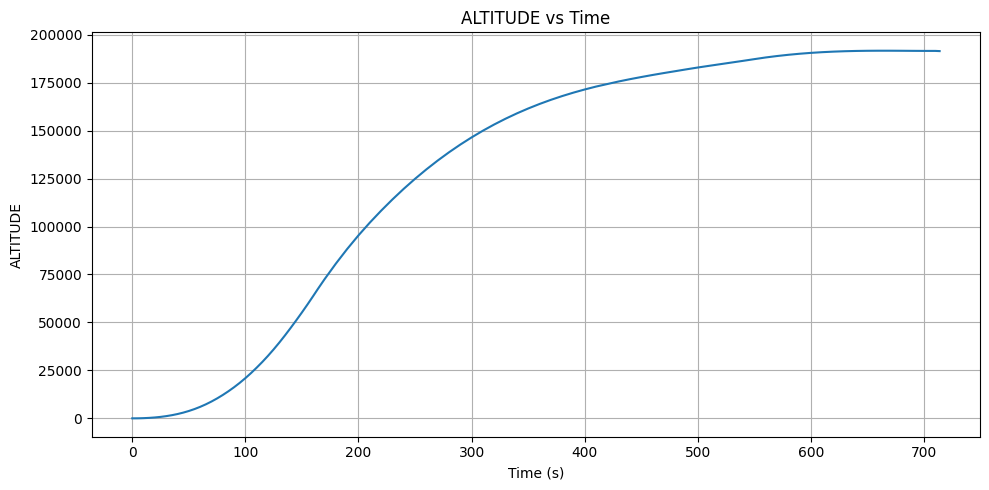

In [26]:
plot_parameters(datas)

### Plotting Groundtrack

In [27]:
def groundtrack(data):
    plt.figure(figsize=(10,5))
    plt.plot(data['LONG'], data['GC LAT'])
    plt.xlabel("Longitude")
    plt.ylabel('Latitude')
    plt.title('Apollo 10 Ground Track')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

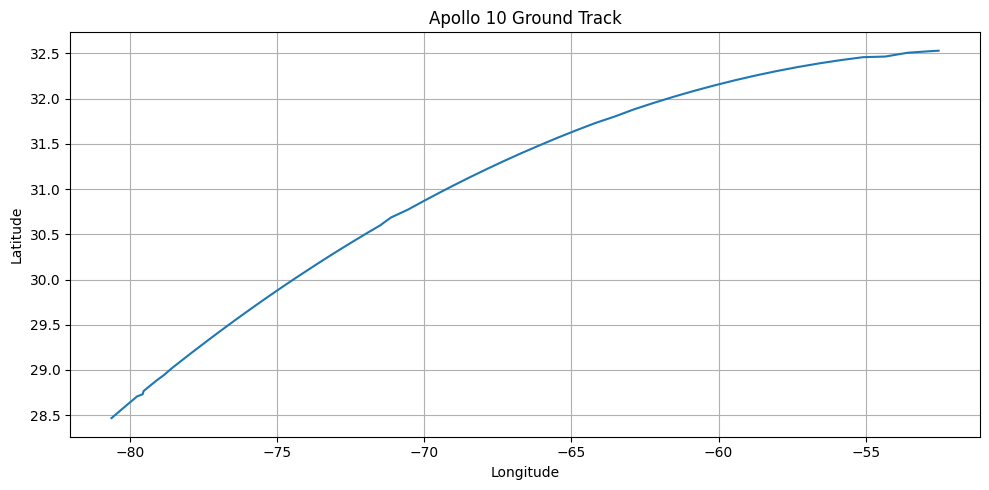

In [28]:
groundtrack(datas)

### Plotting Groundtrack on map

In [42]:
def groundtrack_map(data):
    plt.figure(figsize=(10,5))
    im1 = plt.imread(r'maps\NE1_50M_SR_W_1080.png')
    plt.imshow(im1, extent = [-180, 180, -90, 90])
    plt.scatter(data['LONG'], data['GC LAT'], color='black')
    plt.xlabel("Longitude")
    plt.ylabel('Latitude')
    plt.title('Ground Track on World Map')

    plt.figure(figsize=(10,8))
    im2 = plt.imread(r'maps\NE1_50M_SR_W_CROPPED_1080.png')
    plt.imshow(im2, extent = [-120, -30, 15, 60])
    plt.scatter(data['LONG'], data['GC LAT'], color='black')
    plt.xlabel("Longitude")
    plt.ylabel('Latitude')
    plt.title('Ground Track on Cropped Map')

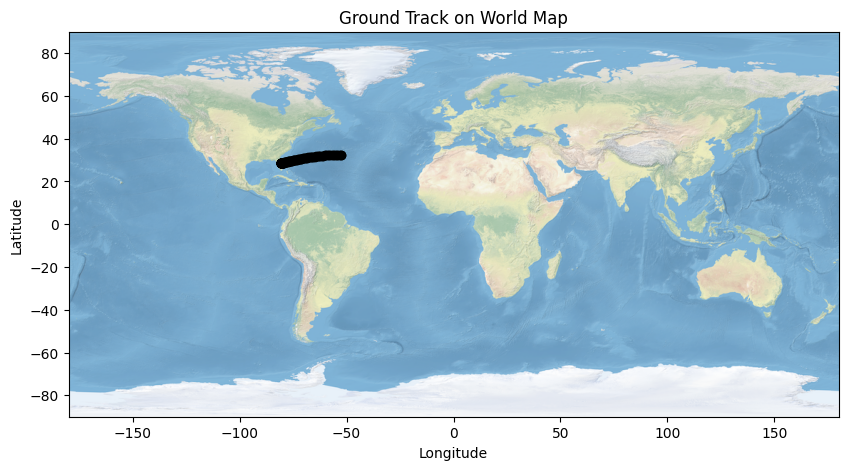

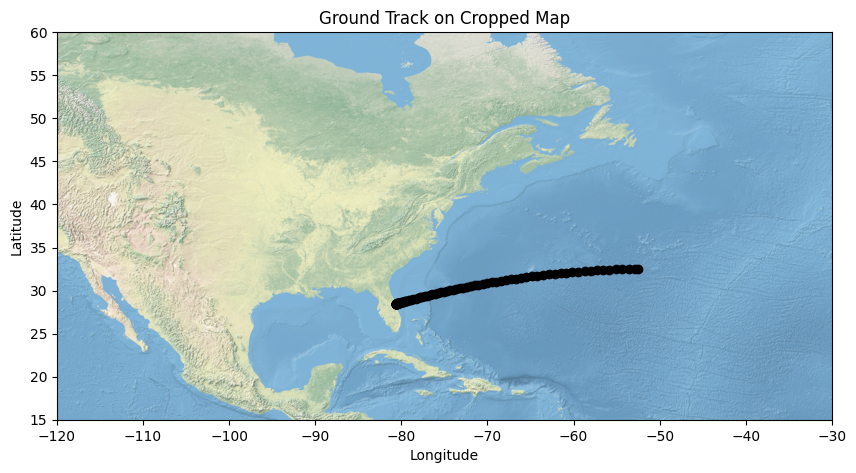

In [43]:
groundtrack_map(datas)